# Import the libraries

In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

In [11]:
def load_stock_data(csv_file):
    df=pd.read_csv(csv_file)
    df['Date'] = pd.to_datetime(df.Date)
    df.set_index('Date',inplace=True)
    return df

# Prepare the Data for ML

In [12]:
def prepare_data(df, forecat_days=30):
    df=df[["Close"]].copy()
    df["Prediction"] = df[["Close"]].shift(-forecat_days)
    X=np.array(df.drop(["Prediction"],axis=1))[:-forecat_days] 
    y=np.array(df["Prediction"])[:-forecat_days]
    return X,y,df  

# Trian and Predict Future Values

In [13]:
def train_and_predict(X, y, df, forecast_days=30):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = LinearRegression()
    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mse = mean_squared_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    print("Model Evaluation")
    print(f"MSE: {mse:.2f}")
    print(f"R2: {r2:.4f}")

    X_future=np.array(df.drop(["Prediction"],axis=1))[-forecast_days:]
    future_predictions=model.predict(X_future)
    
    return future_predictions

In [14]:
def plot_prediction(df, future_predictions):
    import pandas as pd
    import matplotlib.pyplot as plt

    last_date = df.index[-1]
    future_days = len(future_predictions)

    future_dates = pd.date_range(
        start=last_date + pd.Timedelta(days:=1),
        periods=future_days
    )

    plt.figure(figsize=(12, 6))

    plt.plot(df["Close"], label="Historical Close Price")
    plt.plot(future_dates, future_predictions, label="Predicted Close Price", linestyle="--")

    plt.xlabel("Date")
    plt.ylabel("Close Price")
    plt.title("Stock Price Prediction")
    plt.legend()
    plt.show()

In [ ]:
forrecast_days=30
stock_data=load_stock_data("stock_data.csv")
print(stock_data)

                  Open        High         Low       Close   Adj Close  \
Date                                                                     
2015-01-26   15.591000   15.650000   15.376000   15.483000   15.483000   
2015-01-27   15.315000   15.512000   15.131500   15.337500   15.337500   
2015-01-28   15.490500   15.575500   15.190000   15.195500   15.195500   
2015-01-29   15.236500   15.640000   14.966500   15.589000   15.589000   
2015-01-30   17.316000   17.975000   17.037001   17.726500   17.726500   
...                ...         ...         ...         ...         ...   
2024-01-19  153.830002  155.759995  152.740005  155.339996  155.339996   
2024-01-22  156.889999  157.050003  153.899994  154.779999  154.779999   
2024-01-23  154.850006  156.210007  153.929993  156.020004  156.020004   
2024-01-24  157.800003  158.509995  156.479996  156.869995  156.869995   
2024-01-25  156.949997  158.509995  154.550003  157.750000  157.750000   

               Volume  
Date         

Model Evaluation
MSE: 111.72
R2: 0.9529


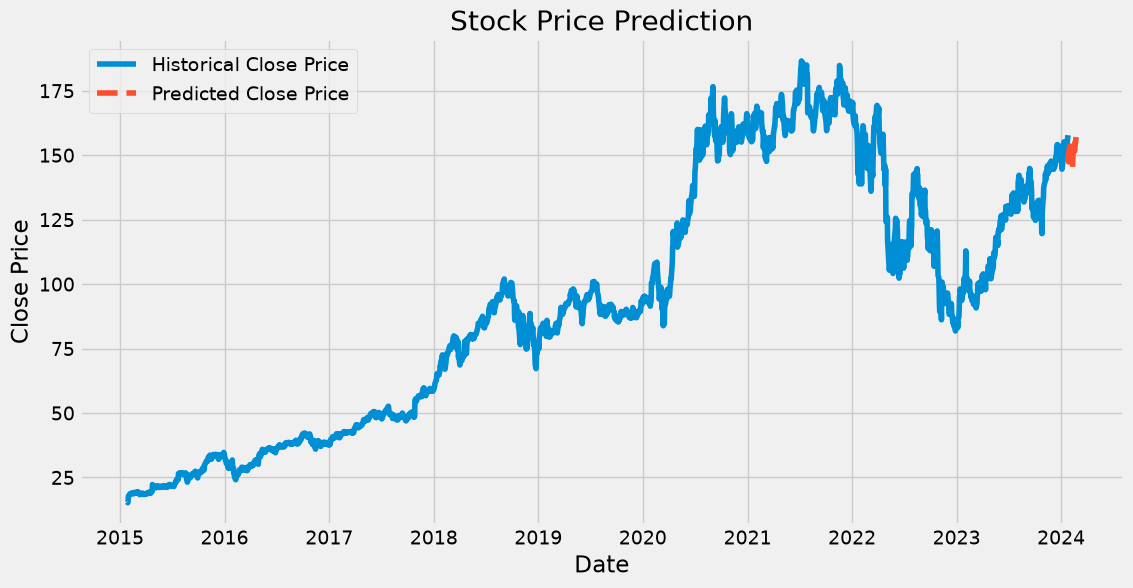

Future Price Predictions
[147.45244977 148.76628745 147.39448827 149.85793682 153.81877679
 153.54826727 151.93495382 153.59657303 153.19083097 153.1811762
 153.11354447 153.15219545 151.7610703  149.8192868  148.40885114
 144.64123419 145.28849052 149.01747196 151.21041098 153.49030675
 154.89108667 154.35009661 152.93966192 151.538882   153.26811747
 155.0456587  154.50466962 155.70258527 156.52372512 157.37386022]


In [24]:
X,y,df=prepare_data(stock_data,forrecast_days)
future_predictions=train_and_predict(X,y,df,forrecast_days)
plot_prediction(df,future_predictions)
print("Future Price Predictions")
print(future_predictions)